# Car Price Prediction with Machine Learning

**Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

**Dataset:** "Vehicle dataset from cardekho" on Kaggle.

> **Before running this notebook:** download the dataset CSV from Kaggle and place it in the same folder as this notebook. Update the filename in the cell below if it differs (the Cardekho dataset is sometimes named `car data.csv` or `CAR DETAILS FROM CAR DEKHO.csv`).


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

## Step 2: Load the Dataset

In [2]:
df = pd.read_csv('car_data.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Tata Nexon,2019,428777,138337.0,Diesel,Trustmark Dealer,Manual,First Owner
1,Mahindra XUV500,2006,171778,6311.0,Diesel,Individual,Automatic,Fourth & Above Owner
2,Maruti Alto,2014,174436,157730.0,Diesel,Dealer,Manual,First Owner
3,Honda Jazz,2008,118687,42606.0,Diesel,Trustmark Dealer,Manual,First Owner
4,Tata Tiago,2008,71557,155969.0,Electric,Individual,Manual,First Owner


In [3]:
df.shape

(510, 8)

## Step 3: Data Cleaning

In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 name             0
year             0
selling_price    0
km_driven        5
fuel             5
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows: 10


In [5]:
# Drop duplicates
df = df.drop_duplicates()

# Handle missing values - drop rows with nulls in critical columns
df = df.dropna(subset=['fuel', 'km_driven'])

# Standardise inconsistent categorical values (e.g. "Petrol" vs "petrol")
df['fuel'] = df['fuel'].str.strip().str.title()
df['transmission'] = df['transmission'].str.strip().str.title()
df['seller_type'] = df['seller_type'].str.strip().str.title()
df['owner'] = df['owner'].str.strip().str.title()

print("Shape after cleaning:", df.shape)
print("\nUnique fuel values after cleaning:", df['fuel'].unique())

Shape after cleaning: (495, 8)

Unique fuel values after cleaning: <StringArray>
['Diesel', 'Electric', 'Petrol', 'Cng']
Length: 4, dtype: str


## Step 4: Feature Engineering

In [6]:
# Car age from year
current_year = 2021
df['car_age'] = current_year - df['year']

# Extract brand from the car name column (first word)
df['brand'] = df['name'].apply(lambda x: str(x).split()[0])

df[['name', 'brand', 'year', 'car_age']].head()

,name,brand,year,car_age
0,Tata Nexon,Tata,2019,2
1,Mahindra XUV500,Mahindra,2006,15
2,Maruti Alto,Maruti,2014,7
3,Honda Jazz,Honda,2008,13
4,Tata Tiago,Tata,2008,13


## Step 5: Exploratory Data Analysis

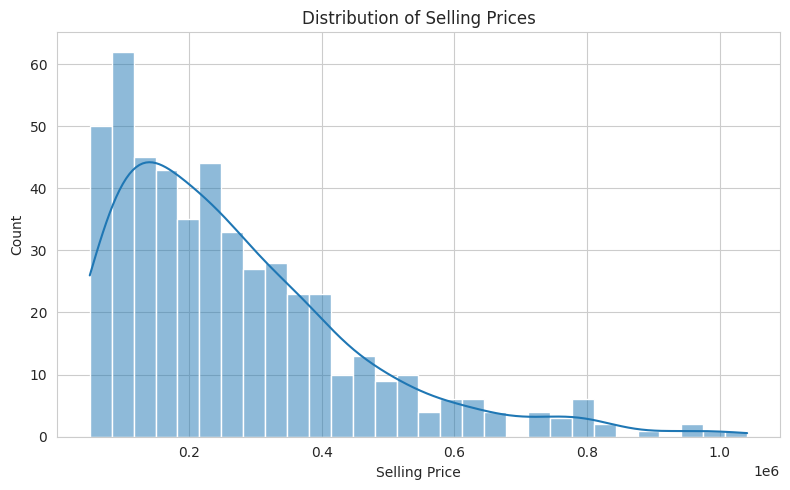

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['selling_price'], bins=30, kde=True)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.tight_layout()
plt.show()

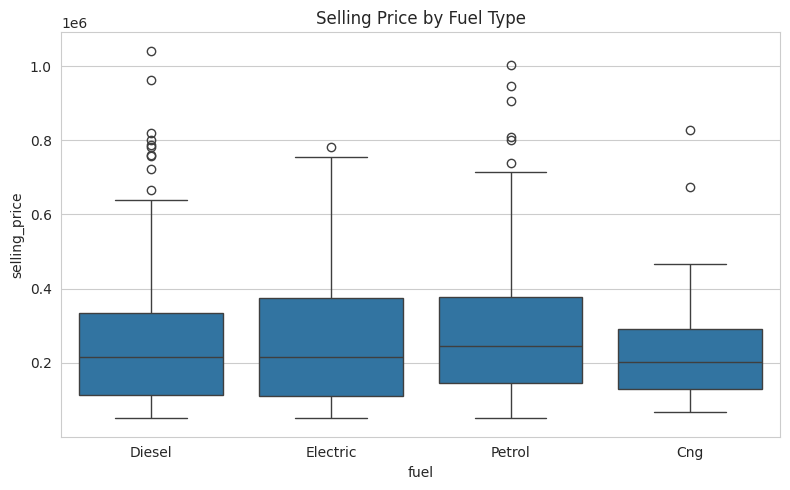

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='fuel', y='selling_price', data=df)
plt.title('Selling Price by Fuel Type')
plt.tight_layout()
plt.show()

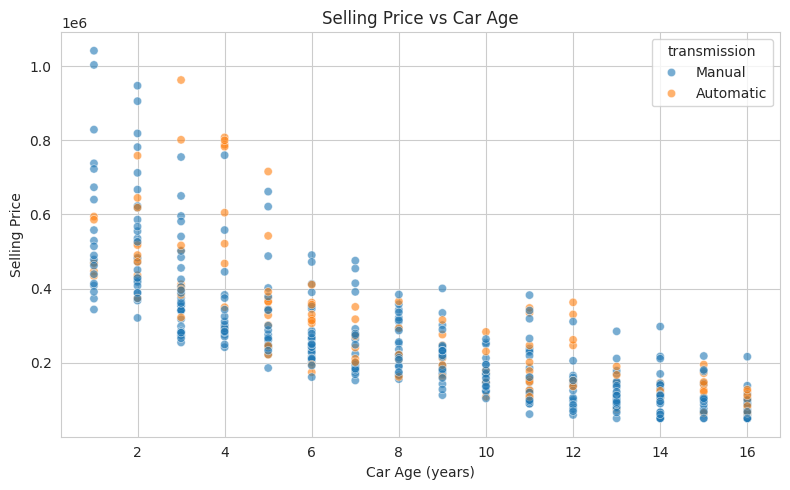

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='car_age', y='selling_price', hue='transmission', data=df, alpha=0.6)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()

**Observations:** Selling price is right-skewed, with most cars priced lower and a long tail of expensive vehicles. Diesel and automatic cars tend to command higher prices. As expected, selling price drops as car age increases.

## Step 6: Encode Categorical Variables

In [10]:
# Keep only the top N brands to avoid too many sparse columns; group rare ones as 'Other'
top_brands = df['brand'].value_counts().nlargest(10).index
df['brand'] = df['brand'].apply(lambda x: x if x in top_brands else 'Other')

categorical_cols = ['brand', 'fuel', 'seller_type', 'transmission', 'owner']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,name,year,selling_price,km_driven,car_age,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Renault,...,brand_Volkswagen,fuel_Diesel,fuel_Electric,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner
0,Tata Nexon,2019,428777,138337.0,2,False,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False
1,Mahindra XUV500,2006,171778,6311.0,15,False,False,True,False,False,...,False,True,False,False,True,False,False,True,False,False
2,Maruti Alto,2014,174436,157730.0,7,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,False
3,Honda Jazz,2008,118687,42606.0,13,True,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False
4,Tata Tiago,2008,71557,155969.0,13,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False


## Step 7: Feature Correlation Heatmap

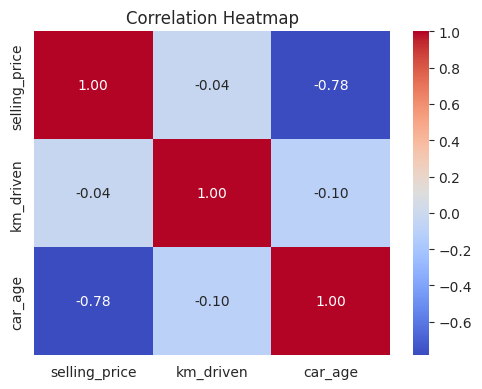

In [11]:
numeric_cols = ['selling_price', 'km_driven', 'car_age']
corr = df_encoded[numeric_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations:** Car age typically shows a negative correlation with selling price (older cars are worth less), while km driven also tends to correlate negatively, though usually less strongly than age.

## Step 8: Train/Test Split

In [12]:
feature_cols = [c for c in df_encoded.columns if c not in ['name', 'year', 'selling_price']]
X = df_encoded[feature_cols]
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (396, 20)
Testing set size: (99, 20)


## Step 9: Train Regression Models

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Linear Regression trained.


Random Forest Regressor trained.
Gradient Boosting Regressor trained.


## Step 10: Evaluate Models

In [14]:
results = {}

for name, model in models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    print(f"\n{'='*45}")
    print(f"Model: {name}")
    print(f"{'='*45}")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2 Score: {r2:.4f}")


Model: Linear Regression
MAE:  52,344.24
RMSE: 70,840.64
R2 Score: 0.8402

Model: Random Forest Regressor
MAE:  37,781.01
RMSE: 49,142.64
R2 Score: 0.9231

Model: Gradient Boosting Regressor
MAE:  32,871.25
RMSE: 44,967.98
R2 Score: 0.9356


In [15]:
results_df = pd.DataFrame(results).T.sort_values(by='R2', ascending=False)
results_df

,MAE,RMSE,R2
Gradient Boosting Regressor,32871.253404,44967.984357,0.935607
Random Forest Regressor,37781.006717,49142.642566,0.923096
Linear Regression,52344.240283,70840.637792,0.840192


/tmp/ipykernel_538/1224460477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['R2'], palette='viridis')


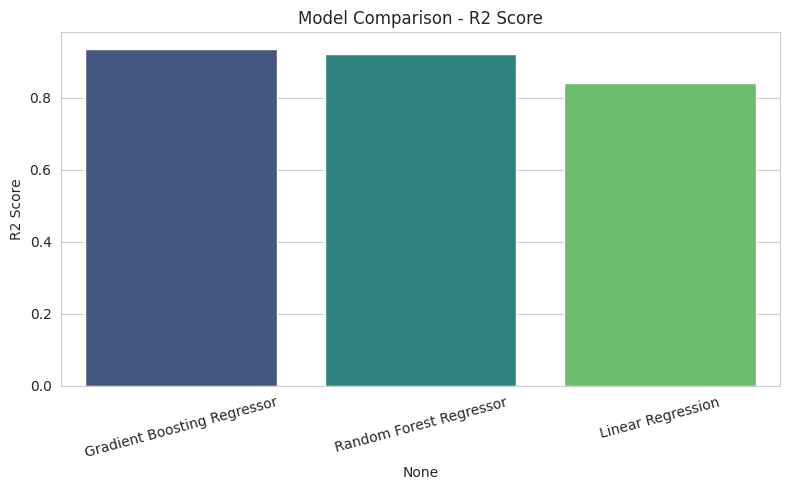

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.index, y=results_df['R2'], palette='viridis')
plt.title('Model Comparison - R2 Score')
plt.ylabel('R2 Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Best-performing model:** based on the R2, MAE, and RMSE values above, the best model is the one with the highest R2 score (closer to 1 is better) and the lowest MAE/RMSE. Tree-based ensemble models (Random Forest, Gradient Boosting) typically outperform plain Linear Regression on this kind of data because car pricing has non-linear relationships (e.g. steep depreciation in the first few years, brand premium effects) that linear models can't capture well.

## Step 11: Feature Importance (Best Model)

/tmp/ipykernel_538/3962873919.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='mako')


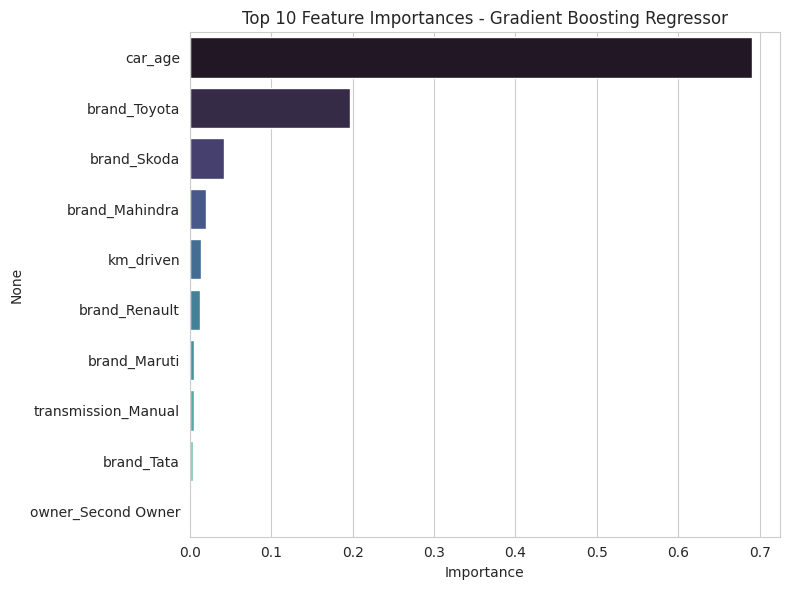

In [17]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette='mako')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(best_model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
    print(coefs.head(10))

**Observations:** Car age and km driven are typically among the strongest predictors of selling price, along with brand (premium brands hold value differently) and transmission type.

## Conclusion

This notebook cleaned and engineered features from used car listing data, explored price distributions across fuel type and car age, encoded categorical variables, and trained three regression models. The best-performing model (see results table above) was selected based on R2, MAE, and RMSE, and its feature importance analysis confirms that car age, mileage, and brand are the primary drivers of resale price.